In [35]:
import os
import sys
import glob
import pickle
import random
import shutil
import zipfile
from tqdm import tqdm
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as opt
from torch.utils.data import Dataset, DataLoader, Subset

### FILES ###
import shutil  # delate directory
import zipfile  # extract a directory

from sklearn.model_selection import train_test_split  # train and test split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [36]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [37]:
# DELETE A DIRECTORY FROM CONTENT

folder = "DATASET_SHARP\doppler_traces"

if os.path.exists(folder):
    shutil.rmtree(folder)
    print("Delated directory")
else:
    print("No delated directory")

Delated directory


In [38]:
# RETURN THE ACTIONS FOR EACH DIRECTORY

def getActions(folder_path):

    actions = []

    for filename in os.listdir(folder_path):

        x = filename.split("_")

        action = x[1]
        if len(action) > 1:
            action =  action[0]

        if action not in actions:
            actions.append(action)

    actions.sort()

    print("Actions:", actions)

    return actions

In [39]:
import zipfile
import os

zip_path = os.path.join("DATASET_SHARP", "doppler_traces.zip")
extract_path = os.path.join("DATASET_SHARP", "doppler_traces")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Estrazione completata.")

Estrazione completata.


In [40]:
# LISTA DELLE CARTELLE DEL DATASET

ROOT_PATH = "DATASET_SHARP\doppler_traces"
#print(os.listdir(ROOT_PATH))
folders = []
for set in os.listdir(ROOT_PATH):

    sets_path = os.path.join(ROOT_PATH, set)

    for folder_name in sorted(os.listdir(sets_path)):

        folder_path = os.path.join(sets_path, folder_name)

        # Considera solo le cartelle
        if not os.path.isdir(folder_path):
            continue

        folders.append(folder_path)

print(folders)

['DATASET_SHARP\\doppler_traces\\doppler_traces\\S1a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S1b', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S1c', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S2a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S2b', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S3a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S4a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S4b', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S5a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S6a', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S6b', 'DATASET_SHARP\\doppler_traces\\doppler_traces\\S7a']


In [41]:
# EXTRACT DATASET

complete_dataset = {}

for i in range(0, len(folders)):

    folder = folders[i]
    actions = getActions(folder)
    dataset_array = {}

    for action in actions:
        dataset_array[action] = []

    folder_name = os.path.basename(folder)
    for action in actions:
        #print(action)
        for filename in os.listdir(folder):
            marker = f"_{action}"
            if marker in filename:
                file_path = os.path.join(folder, filename)

                with open(file_path, "rb") as fp:
                    doppler = pickle.load(fp)
                dataset_array[action].append(doppler)

    complete_dataset[folder_name] = dataset_array

Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']
Actions: ['E', 'J', 'L', 'R', 'W']
Actions: ['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']


In [42]:
# WINDOW OF 1@(340 x 100)

def create_sliding_windows(complete_dataset, window_length=340, stride=340):
    X = []
    y = []
    folders = []
    streams = []
    ############################################################
    #print(complete_dataset) ### J is empty ?????
    ######################################################
    for folder_name in complete_dataset:
        print("Cartella: ", folder_name)
        dataset = complete_dataset[folder_name]
        all_windows = {}

        for action in dataset:

            #data = np.asarray(dataset[action])
            data = [np.asarray(x) for x in dataset[action]]
            windows_activity = []
            # elements of each action
            #num_streams, time_length, num_features = np.array(data).shape
            #print(f"Action {action} -> Shape of data: {num_streams}, {time_length}, {num_features}")

            num_streams = len(data)
            #print(f"Action {action} -> num_streams: {num_streams}")

            for stream in range(num_streams):

                stream_data = data[stream]
                time_length, num_features = stream_data.shape
                window = []
                # se lo stream è più corto in partenza della grandezza della finestra
                if time_length < window_length:
                    print("The dataset is less than window size")
                    continue

                start = 0
                end = window_length
                while end <= time_length:
                    window = data[stream][start:end, :]
                    #windows_stream.append(window)
                    X.append(window)
                    y.append(action)
                    folders.append(folder_name)
                    streams.append(stream)
                    start += stride
                    end += stride

            print(f"Action {action} -> Shape of data: {num_streams}, {time_length}, {num_features}")
            del data

        del dataset

    return X, y, folders, streams


X, y, folders, streams = create_sliding_windows(complete_dataset, stride=85)


Cartella:  S1a
Action C -> Shape of data: 4, 18766, 100
Action E -> Shape of data: 4, 18700, 100
Action H -> Shape of data: 4, 19064, 100
Action J -> Shape of data: 8, 8708, 100
Action L -> Shape of data: 4, 18842, 100
Action R -> Shape of data: 4, 19269, 100
Action S -> Shape of data: 4, 19009, 100
Action W -> Shape of data: 4, 19295, 100
Cartella:  S1b
Action C -> Shape of data: 4, 18803, 100
Action E -> Shape of data: 4, 18270, 100
Action H -> Shape of data: 4, 18707, 100
Action J -> Shape of data: 8, 8667, 100
Action L -> Shape of data: 4, 19329, 100
Action R -> Shape of data: 4, 19253, 100
Action S -> Shape of data: 4, 18922, 100
Action W -> Shape of data: 4, 18927, 100
Cartella:  S1c
Action C -> Shape of data: 4, 18533, 100
Action E -> Shape of data: 4, 18929, 100
Action H -> Shape of data: 4, 19053, 100
Action J -> Shape of data: 8, 8784, 100
Action L -> Shape of data: 4, 19547, 100
Action R -> Shape of data: 4, 19197, 100
Action S -> Shape of data: 4, 19017, 100
Action W -> Sha

In [43]:
index = np.random.randint(0, len(X))
print("Index: ", index)
print(type(X[index]))
print("Element in X: ", X[index].shape)
print("Element in y: ", y[index])
print("Element in folders: ", folders[index])
print("Element in streams: ", streams[index])

Index:  15795
<class 'numpy.ndarray'>
Element in X:  (340, 100)
Element in y:  H
Element in folders:  S1c
Element in streams:  0


In [44]:
label_map = {
    "W": 0,
    "R": 1,
    "J": 2,
    #"J2": 2,
    "L": 3,
    "S": 4,
    "C": 5,
    "H": 6,
    "E": 7,
    #    "H": 8
}


class DopplerDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        element = self.dataset[idx]
        # Convert to float32
        x = torch.from_numpy(element["data"]).float()
        # Add channel dimension -> (1, 340, 100)
        x = x.unsqueeze(0)

        activity = element["label"]

        y = torch.tensor(label_map[activity], dtype=torch.long)

        z = element["folder"]

        w = element["stream"]

        return x, y, z, w


In [45]:
# DATASET, TRAINING, TEST
dataset = [
    {
        "data": data,
        "label": label,
        "folder": folder,
        "stream": stream
    }
    for data, label, folder, stream
    in zip(X, y, folders, streams)
]

dataset_S1 = []
dataset_test_external = []

for sample in dataset:
    if sample["folder"].startswith("S1"):
        dataset_S1.append(sample)
    else:
        dataset_test_external.append(sample)

labels = []

for sample in dataset_S1:
    labels.append(sample["label"])

unique_labels = sorted({s["label"] for s in dataset_S1})
print(unique_labels)

['C', 'E', 'H', 'J', 'L', 'R', 'S', 'W']


In [46]:
train_S1_dataset, test_S1_dataset = train_test_split(
    dataset_S1,
    test_size=0.40,
    random_state=42,
    stratify=labels
)

validation_S1_dataset, test_S1_dataset = train_test_split(
    test_S1_dataset,
    test_size=0.50,
    random_state=42,
    stratify=[s["label"] for s in test_S1_dataset]
)

In [47]:
train_S1_dataset = DopplerDataset(train_S1_dataset)
validation_S1_dataset = DopplerDataset(validation_S1_dataset)
test_S1_dataset = DopplerDataset(test_S1_dataset)

In [48]:
train_labels = [s["label"] for s in dataset_S1]

print(Counter(train_labels))

Counter({'L': 2672, 'R': 2672, 'W': 2648, 'H': 2636, 'S': 2636, 'C': 2600, 'E': 2588, 'J': 2360})


In [49]:
# CONTENUTO CODICE

print("Dataset: ", dataset[0])
print(dataset[0]["data"].shape)
print("Dataset completo:", len(dataset))
print("Dataset S1:", len(dataset_S1))
print("Dataset test esterno:", len(dataset_test_external))
print("Train S1:", len(train_S1_dataset))
print("Test S1:", len(test_S1_dataset))

#print(train_S1_dataset[0]["data"].shape)
print(train_S1_dataset[0][0].shape)
from collections import Counter

#print(Counter(labels_train))

Dataset:  {'data': array([[0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       ...,
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573],
       [0.06309573, 0.06309573, 0.06309573, ..., 0.06309573, 0.06309573,
        0.06309573]], shape=(340, 100)), 'label': 'C', 'folder': 'S1a', 'stream': 0}
(340, 100)
Dataset completo: 74124
Dataset S1: 20812
Dataset test esterno: 53312
Train S1: 12487
Test S1: 4163
torch.Size([1, 340, 100])


In [50]:
# DATA AUGMENTATION

def augmentation(x):
    x = x.clone()
    #Gaussian noise
    if torch.rand(1) < 0.5:
        sigma = torch.empty(1).uniform_(0.01, 0.03) * x.std()
        x += sigma * torch.randn_like(x)
    #Amplitude scaling
    if torch.rand(1) < 0.5:
        scale = torch.empty(1).uniform_(0.9, 1.1)
        x *= scale
    #Time shift
    if torch.rand(1) < 0.5:
        shift = torch.randint(-8, 9, (1,)).item()
        x = torch.roll(x, shifts=shift, dims=1)

    return x


class AugmentedDataset(Dataset):

    def __init__(self, base_dataset, augment=True):
        self.base_dataset = base_dataset
        self.augment = augment

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y, z, w = self.base_dataset[idx]
        if self.augment:
            x = augmentation(x)
        return x, y, z, w


aug_train_S1_dataset = AugmentedDataset(train_S1_dataset, augment=True)

In [51]:
#Network Definition

NUM_LABELS = 8


class BaseNet(nn.Module):
    def __init__(self):
        super().__init__()

        print("Network Initialized")

        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=5, kernel_size=2, stride=2),
            nn.BatchNorm2d(5),
            nn.ReLU())
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.Conv2d(in_channels=6, out_channels=9, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(9),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=15, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )

        self.block2 = nn.Sequential(
            nn.Dropout(0.3),
            nn.LazyLinear(out_features=NUM_LABELS),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        h = torch.cat([b1, b2, b3], dim=1)
        h = self.block1(h)
        h = h.flatten(1)
        out = self.block2(h)

        return out

In [52]:
print(type(train_S1_dataset[0]))

<class 'tuple'>


In [53]:
batch_size = 128
num_workers = 0
pin_memory = torch.cuda.is_available()

train_dataloader = DataLoader(aug_train_S1_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
valid_dataloader = DataLoader(validation_S1_dataset, batch_size=len(validation_S1_dataset), shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
test_dataloader = DataLoader(test_S1_dataset, batch_size=len(test_S1_dataset), shuffle=False,
                             num_workers=num_workers, pin_memory=pin_memory)

In [54]:
model = BaseNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
train_loss_log = []
val_loss_log = []
val_acc_log = []
train_acc_log = []

best_val = float("inf")
patience = 5
counter = 0

optimizer = opt.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

loss_fn = nn.CrossEntropyLoss()

epochs = 1

for epoch in range(epochs):
    model.train()
    print(f"Epoch:{epoch + 1}")
    train_iterator = tqdm(train_dataloader)
    train_loss = []
    tr_correct = 0
    tr_total = 0
    for batch_x, batch_y, _, _ in train_iterator:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_x)

        loss = loss_fn(y_pred, batch_y)

        model.zero_grad()
        loss.backward()
        optimizer.step()
        loss_batch = loss.detach().cpu().numpy()
        train_loss.append(loss_batch)

        pred = y_pred.argmax(dim=1)
        tr_correct += (pred == batch_y).sum().item()
        tr_total += batch_y.size(0)

    tr_accuracy = tr_correct / tr_total

    train_loss = np.mean(train_loss)
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    print(f"Accuracy : {tr_accuracy:.2%}")
    train_loss_log.append(train_loss)
    train_acc_log.append(tr_accuracy)

    val_loss = []
    model.eval()
    val_correct = 0
    val_total = 0

    val_iterator = tqdm(valid_dataloader)

    with torch.no_grad():
        for batch_x, batch_y, _, _ in val_iterator:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            out = model(batch_x)

            loss = loss_fn(out, batch_y)
            # scheduler.step(loss)

            loss_batch = loss.detach().cpu().numpy()
            val_loss.append(loss_batch)
            pred = out.argmax(dim=1)
            val_correct += (pred == batch_y).sum().item()
            val_total += batch_y.size(0)

        val_accuracy = val_correct / val_total
        val_loss = np.mean(val_loss)
        scheduler.step(val_loss)

        print(f"AVERAGE VAL LOSS: {np.mean(val_loss)}")
        print(f"Accuracy : {val_accuracy:.2%}")
        val_loss_log.append(val_loss)

        val_acc_log.append(val_accuracy)

        if val_loss < best_val:
            best_val = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping")
            break


Network Initialized
Epoch:1


100%|██████████| 98/98 [02:16<00:00,  1.39s/it]


AVERAGE TRAIN LOSS: 1.5875544548034668
Accuracy : 34.96%


100%|██████████| 1/1 [00:28<00:00, 28.31s/it]

AVERAGE VAL LOSS: 1.3611509799957275
Accuracy : 39.00%


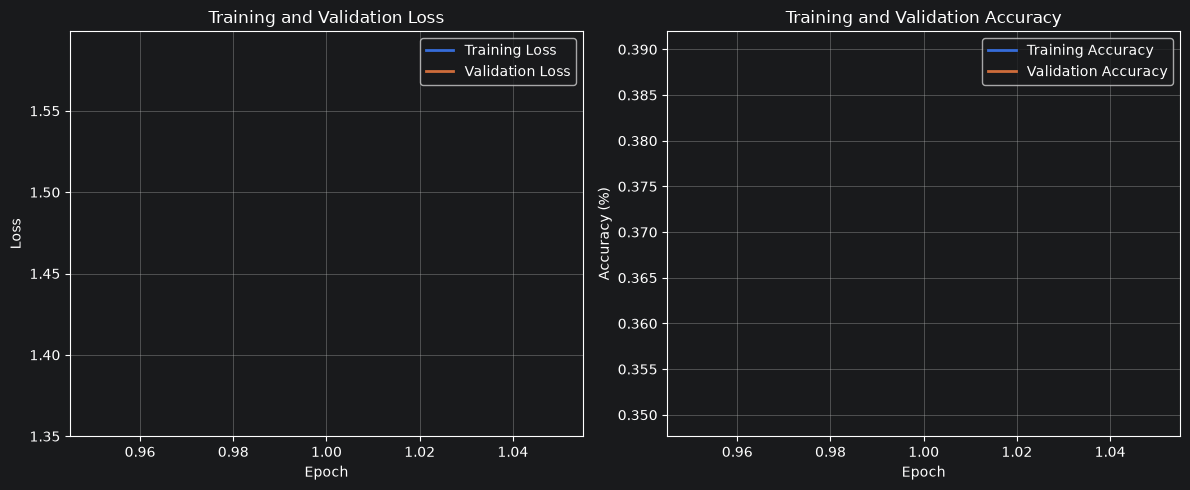

In [55]:
epochs = range(1, len(train_loss_log) + 1)

plt.figure(figsize=(12, 5))

# Losses
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_log, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss_log, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

# Accuracies

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_log, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc_log, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

all_inputs = []
all_outputs = []
all_labels = []

correct = 0
total = 0
total_loss = 0.0

with torch.no_grad():
    test_iterator = tqdm(test_dataloader)
    for batch_x, batch_y, _, _ in test_iterator:
        out = model(batch_x)
        #print("True label:", batch_y, "Predicted label:", out)
        all_inputs.append(batch_x)
        all_outputs.append(out)
        all_labels.append(batch_y)
        loss = loss_fn(out, batch_y)

        pred = out.argmax(dim=1)
        total_loss += loss.item() * batch_x.size(0)

        correct += (pred == batch_y).sum().item()
        total += batch_y.size(0)

avg_loss = total_loss / total
accuracy = correct / total

all_inputs = torch.cat(all_inputs)
all_outputs = torch.cat(all_outputs)
all_labels = torch.cat(all_labels)

test_loss = loss_fn(all_outputs, all_labels)
print(f"AVERAGE TEST LOSS: {test_loss}")
print(f"Test loss: {avg_loss:.4f}")
print(f"Accuracy : {accuracy:.2%}")

100%|██████████| 1/1 [00:18<00:00, 18.76s/it]


AVERAGE TEST LOSS: 1.3657891750335693
Test loss: 1.3658
Accuracy : 38.72%


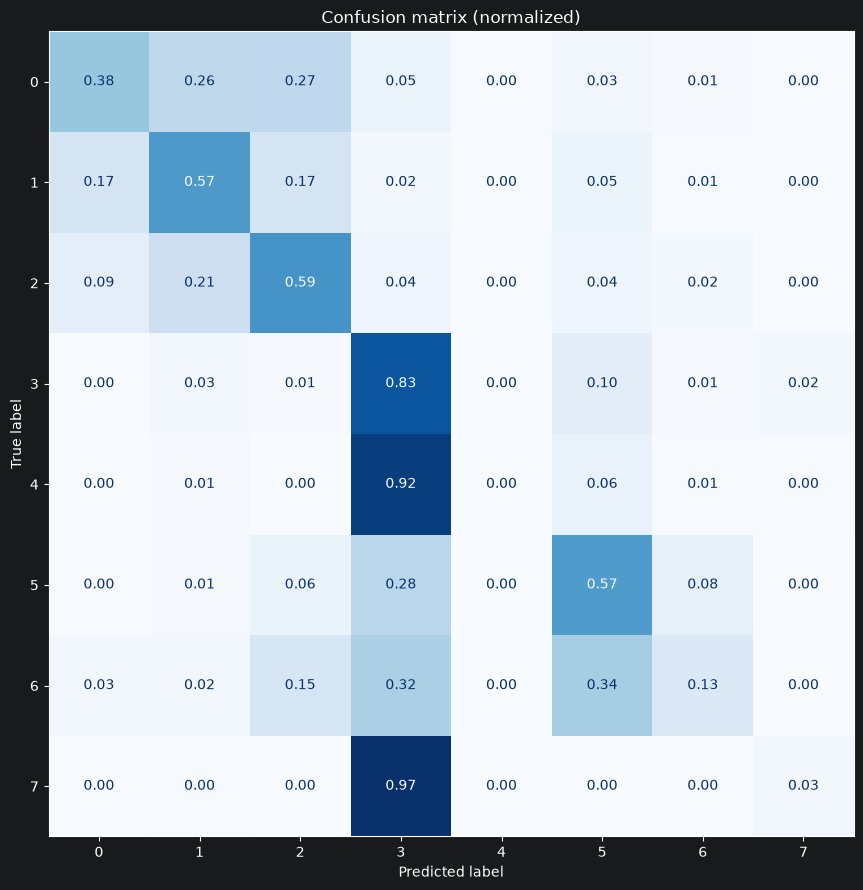

In [57]:
pre_index = torch.tensor([s.argmax() for s in all_outputs])
cm = confusion_matrix(all_labels, pre_index, normalize="true")
class_names = [0, 1, 2, 3, 4, 5, 6, 7]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4, 5, 6, 7])

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Confusion matrix (normalized)")
plt.tight_layout()
plt.show()

In [58]:
"""
Trains a fresh model instance on a TINY fixed subset of the data for
many epochs. If the model can't reach ~100% training accuracy on this
subset, the bug is in the data pipeline / labels / architecture, NOT
in generalization -- fix that before worrying about anything else.

Args:
    model_class: the class (not instance) of your model, e.g. BaseNet
    dataset:     your full training Dataset object (unshuffled subset is fine)
    device:      "cuda" or "cpu"
    n_samples:   how many samples to overfit on (16-32 is plenty)
"""
n_samples = 32
small_ds = Subset(dataset, list(range(n_samples)))
small_loader = DataLoader(DopplerDataset(small_ds), batch_size=1, shuffle=True)

model = BaseNet().to(device)
optimizer = opt.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

print(f"Sanity check: overfitting {n_samples} samples for 200 epochs...")
for epoch in range(200):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    small_iterator = tqdm(small_loader)
    for batch_x, batch_y, _, _ in small_iterator:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = loss_fn(y_pred, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        correct += (y_pred.argmax(dim=1) == batch_y).sum().item()
        total += batch_x.size(0)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  epoch {epoch + 1:4d} | loss {total_loss / total:.4f} | "
              f"acc {correct / total:.4f}")

final_acc = correct / total
if final_acc > 0.95:
    print(f"\n✓ PASSED")
else:
    print(f"\n✗ FAILED")


Network Initialized
Sanity check: overfitting 32 samples for 200 epochs...


100%|██████████| 32/32 [00:00<00:00, 39.63it/s]


  epoch    1 | loss 0.2515 | acc 0.9062


100%|██████████| 32/32 [00:00<00:00, 72.55it/s]


  epoch   20 | loss 0.0000 | acc 1.0000


...

  epoch  160 | loss 0.0000 | acc 1.0000


100%|██████████| 32/32 [00:00<00:00, 79.36it/s]


  epoch  180 | loss 0.0000 | acc 1.0000


100%|██████████| 32/32 [00:00<00:00, 70.75it/s]

  epoch  200 | loss 0.0000 | acc 1.0000

✓ PASSED


In [59]:
# CLASS PERSON DATASET

class PersonDataset(Dataset):
    def __init__(self, dataset_people):
        self.dataset_people = dataset_people

    def __len__(self):
        return len(self.dataset_people)

    def __getitem__(self, idx):
        sample = self.dataset_people[idx]

        x = torch.from_numpy(sample["data"]).float()
        x = x.unsqueeze(0)

        activity = torch.tensor(label_map[sample["label"]], dtype=torch.long)

        person = torch.tensor(int(sample["person"]), dtype=torch.long)

        folder = sample["folder"]

        # stream = sample["stream"]

        return x, activity, person, folder

In [61]:
# GENERATION OF DATASET WRT PEOPLE

person_map = {
    "S1": 0,
    "S2": 0,
    "S3": 1,
    "S4": 0,
    "S5": 1,
    "S6": 0,
    "S7": 2
}

y_people = []

for folder in folders:

    set_name = folder[:2]
    if set_name not in person_map:
        raise ValueError(f"Set '{set_name}' non riconosciuto.")
    person = person_map[set_name]

    y_people.append(person)

dataset_people = [
    {
        "data": data,
        "label": label,
        "person": person,
        "folder": folder
    }
    for data, label, person, folder
    in zip(X, y, y_people, folders)
]

In [62]:
# GENERAL CHECK

# CHECK DATASET PEOPLE

from collections import Counter

print("Numero campioni X:", len(X))
print("Numero etichette y:", len(y))
print("Numero persone:", len(y_people))
print("Numero folder:", len(folders))
print("Numero dataset_people:", len(dataset_people))

print("\nPrime 10 associazioni:")

for sample in dataset_people[:10]:
    print(
        sample["folder"],
        sample["label"],
        sample["person"]
    )

print("\nCampioni per persona:")

counter_people = Counter(y_people)

for person, count in sorted(counter_people.items()):
    print(
        f"Persona {person}: {count}"
    )

Numero campioni X: 74124
Numero etichette y: 74124
Numero persone: 74124
Numero folder: 74124
Numero dataset_people: 74124

Prime 10 associazioni:
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0
S1a C 0

Campioni per persona:
Persona 0: 54456
Persona 1: 12952
Persona 2: 6716


In [65]:
print(set)
del set

doppler_traces


In [66]:
# CHECK ACTIVITY-PERSON PAIRS

from collections import defaultdict

people_per_activity = defaultdict(set)
samples_per_activity_person = Counter()

for sample in dataset_people:
    activity = sample["label"]
    person = sample["person"]

    people_per_activity[activity].add(person)
    samples_per_activity_person[(activity, person)] += 1

print("\nPersone presenti per ogni attività:")

for activity in sorted(people_per_activity):
    people = sorted(people_per_activity[activity])

    print(
        f"Attività {activity}: "
        f"persone {people} "
        f"({len(people)} persone)"
    )

print("\nNumero di campioni per attività e persona:")

for activity in sorted(people_per_activity):

    for person in sorted(people_per_activity[activity]):
        count = samples_per_activity_person[
            (activity, person)
        ]

        print(
            f"Attività {activity} | "
            f"Persona {person} | "
            f"Campioni {count}"
        )

activities_without_cross_person_positives = [
    activity
    for activity, people in people_per_activity.items()
    if len(people) < 2
]

if activities_without_cross_person_positives:
    print(
        "\nATTENZIONE: queste attività sono presenti "
        "per una sola persona:",
        sorted(activities_without_cross_person_positives)
    )
else:
    print(
        "\nOK: tutte le attività sono presenti "
        "per almeno due persone."
    )


Persone presenti per ogni attività:
Attività C: persone [0, 1, 2] (3 persone)
Attività E: persone [0, 1, 2] (3 persone)
Attività H: persone [0, 1, 2] (3 persone)
Attività J: persone [0, 1, 2] (3 persone)
Attività L: persone [0, 1, 2] (3 persone)
Attività R: persone [0, 1, 2] (3 persone)
Attività S: persone [0, 1, 2] (3 persone)
Attività W: persone [0, 1, 2] (3 persone)

Numero di campioni per attività e persona:
Attività C | Persona 0 | Campioni 4276
Attività C | Persona 1 | Campioni 792
Attività C | Persona 2 | Campioni 884
Attività E | Persona 0 | Campioni 9320
Attività E | Persona 1 | Campioni 1816
Attività E | Persona 2 | Campioni 848
Attività H | Persona 0 | Campioni 4312
Attività H | Persona 1 | Campioni 1668
Attività H | Persona 2 | Campioni 884
Attività J | Persona 0 | Campioni 6724
Attività J | Persona 1 | Campioni 1536
Attività J | Persona 2 | Campioni 688
Attività L | Persona 0 | Campioni 9524
Attività L | Persona 1 | Campioni 2700
Attività L | Persona 2 | Campioni 784
Atti

In [ ]:
########## PARTE DA RIVISIONARE ################

In [25]:
# Network definition with contrastive learning

NUM_LABELS = 9

class ContrastiveNet(nn.Module):
    def __init__(self):
        super().__init__()

        print("Network Initialized")

        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=5, kernel_size=2, stride=2),
            nn.ReLU())
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=2, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=6, out_channels=9, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=15, out_channels=3, kernel_size=1, stride=1, padding='same'),
            nn.ReLU()
        )

        #self.block2 = nn.Sequential(
            #nn.Dropout(0.2),
            #nn.LazyLinear(out_features=NUM_LABELS)
        #)

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(25500, out_features=NUM_LABELS)
        )

        self.projection_head = nn.Sequential(
            nn.Linear(25500, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        print("Branch 1:", b1.shape)
        b2 = self.branch2(x)
        print("Branch 2:", b2.shape)
        b3 = self.branch3(x)
        print("Branch 3:", b3.shape)

        h = torch.cat([b1, b2, b3], dim=1)
        print("Concat:", h.shape)

        h = self.block1(h)
        print("Concat:", h.shape)
        h = h.flatten(1)
        print("Flatten:", h.shape)
        act = self.classifier(h) # classification
        print("Out:", act.shape)
        proj = self.projection_head(h) # projection
        proj = nn.functional.normalize(proj, dim=1)

        return act,proj

In [28]:
# DATALOADER -> TRAIN E TEST DATA
labels = [
    sample["label"]
    for sample in dataset_people
]

train_data_people, test_data_people = train_test_split(
    dataset_people,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Dim training:", len(train_data_people))
print("Dim test:", len(test_data_people))

train_dataset_people = PersonDataset(train_data_people)
test_dataset_people = PersonDataset(test_data_people)

augmented_train_dataset_people = AugmentedDataset(
    train_dataset_people,
    augment=True
)

train_loader_people = DataLoader(
    augmented_train_dataset_people,
    batch_size=64,
    shuffle=True
)

test_loader_people = DataLoader(
    test_dataset_people,
    batch_size=64,
    shuffle=False
)

batch_x, batch_activity, batch_person, batch_folder = next(
    iter(train_loader_people)
)

print("Dati:", batch_x.shape)
print("Attività:", batch_activity.shape)
print("Persone:", batch_person.shape)
print("Cartelle:", len(batch_folder))

print("Persone presenti:", torch.unique(batch_person))

Dim training: 59299
Dim test: 14825
Dati: torch.Size([64, 1, 340, 100])
Attività: torch.Size([64])
Persone: torch.Size([64])
Cartelle: 64
Persone presenti: tensor([0, 1, 2])


In [29]:
batch_x = batch_x.to(device)
batch_activity = batch_activity.to(device)
batch_person = batch_person.to(device)

In [30]:
# PER OGNI ATTIVITà -> CHE TIPO DI PERSONE

for activity in torch.unique(batch_activity):

    mask = batch_activity == activity
    people = torch.unique(batch_person[mask])

    print(
        f"Attività {activity.item()} "
        f"-> {mask.sum().item()} campioni "
        f"-> persone {people.tolist()}"
    )

Attività 0 -> 10 campioni -> persone [0, 1]
Attività 1 -> 11 campioni -> persone [0, 1, 2]
Attività 2 -> 11 campioni -> persone [0, 1]
Attività 3 -> 11 campioni -> persone [0, 1, 2]
Attività 4 -> 6 campioni -> persone [0, 1, 2]
Attività 5 -> 3 campioni -> persone [0, 2]
Attività 6 -> 5 campioni -> persone [0, 1]
Attività 7 -> 7 campioni -> persone [0, 1]


In [31]:
# LOSS FUNCTION NT-XENT-LOSS

def NT_Xent_loss(features, activities, people, temperature=0.5):

    #device = features.device
    #batch_size = features.size(0)
    features = nn.functional.normalize(features, dim=1)

    # Similarity matrix
    cos_sim = torch.matmul(features, features.T) / temperature

    # SELF-MASK
    self_mask = torch.eye(
        features.size(0),
        dtype=torch.bool,
        device=cos_sim.device
    )

    # POSITIVE KEYS -> DIFFERENT PEOPLE WITH SAME ACTIVITY
    same_activity = activities[:, None] == activities[None, :]
    different_people = people[:, None] != people[None, :]
    positive_keys = same_activity & different_people & ~self_mask

    # NEGATIVE KEYS -> DIFFERENT ACTIVITIES
    negative_keys = ~same_activity & ~self_mask # & different_people

    # VALID COMPARISON
    valid_keys = (positive_keys | negative_keys)
    # IGNORE INVALID COMPARISON
    masked_similarity = cos_sim.masked_fill(~valid_keys, -9e15)

    # DENOMINATOR
    log_denominator = torch.logsumexp(masked_similarity, dim=1)

    # POSITIVE SIMILARITIES
    #positive_similarities = cos_sim.masked_fill(~positive_keys, 0.0)
    num_positives = positive_keys.sum(dim=1)
    positive_sum = (
        cos_sim * masked_similarity.float()
    ).sum(dim=1)
    mean_positive_similarity = (positive_sum.sum(dim=1) / num_positives.clamp_min(1))

    # LOSS FOR EACH ANCHOR
    loss_per_anchor = (-mean_positive_similarity + log_denominator)

    # Use only anchors with at least one positive
    valid_anchors = num_positives > 0
    if not valid_anchors.any():
        return features.sum() * 0.0

    loss = loss_per_anchor[valid_anchors].mean()

    return loss

In [32]:
model = ContrastiveNet()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = opt.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

temperature = 0.5
lambda_contrastive = 0.1
epochs = 1

for epoch in range(epochs):

    model.train()
    print(f"Epoch: {epoch+1}")
    running_loss = 0.0
    correct = 0
    total = 0

    train_iterator = tqdm(train_loader_people)

    for batch_x, batch_activity, batch_people, batch_folder in train_iterator:

        batch_x = batch_x.to(device)
        batch_activity = batch_activity.to(device)
        batch_people = batch_people.to(device)

        # Forward pass
        activity_logits, projected_features = model(batch_x)

        # Classification loss
        classification_loss = loss_fn(activity_logits, batch_activity)

        # Contrastive loss
        contrastive_loss = NT_Xent_loss(projected_features, batch_activity, batch_people,temperature=temperature)

        # Total loss
        loss = (classification_loss + lambda_contrastive * contrastive_loss)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = activity_logits.argmax(dim=1)

        correct += (
            predicted == batch_activity
        ).sum().item()

        total += batch_activity.size(0)

        train_iterator.set_description(
            f"Train loss: {loss.detach().cpu().item():.4f} | "
            f"CE: {classification_loss.detach().cpu().item():.4f} | "
            f"NT-Xent: {contrastive_loss.detach().cpu().item():.4f}"
        )

    epoch_loss = running_loss / len(train_loader_people)
    epoch_accuracy = 100 * correct / total

    print(f"Train loss: {epoch_loss:.4f}")
    print(f"Train accuracy: {epoch_accuracy:.2f}%")

Network Initialized
Epoch: 1


  0%|          | 0/927 [00:00<?, ?it/s]

Branch 1: torch.Size([64, 1, 170, 50])
Branch 2: torch.Size([64, 5, 170, 50])
Branch 3: torch.Size([64, 9, 170, 50])
Concat: torch.Size([64, 15, 170, 50])
Concat: torch.Size([64, 3, 170, 50])
Flatten: torch.Size([64, 25500])
Out: torch.Size([64, 9])


  0%|          | 0/927 [00:00<?, ?it/s]


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [ ]:
model.eval()

all_outputs = []
all_labels = []

with torch.no_grad():
    test_iterator = tqdm(test_loader_people)
    for batch_x, batch_activity, batch_people, batch_folder in test_iterator:
        batch_x = batch_x.to(device)
        batch_activity = batch_activity.to(device)

        activity_logits, projected_features = model(batch_x) # output

        all_outputs.append(activity_logits)
        all_labels.append(batch_activity)

all_outputs = torch.cat(all_outputs)
all_labels = torch.cat(all_labels)

test_loss = loss_fn(all_outputs,all_labels)
print(f"AVERAGE TEST LOSS: {test_loss:.4f}")

In [ ]:
total_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for batch_x, batch_activity, batch_people, batch_folder in test_loader_people:
        batch_x = batch_x.to(device)
        batch_activity = batch_activity.to(device)

        activity_logits, projected_features = model(batch_x)

        loss = loss_fn(activity_logits, batch_activity)
        total_loss += loss.item() * batch_x.size(0)

        pred = activity_logits.argmax(dim=1)

        correct += ( pred == batch_activity).sum().item()
        total += batch_activity.size(0)

avg_loss = total_loss / total
accuracy = correct / total

print(f"Test loss: {avg_loss:.4f}")
print(f"Accuracy : {accuracy:.2%}")